In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
from sklearn.preprocessing import MultiLabelBinarizer

In [2]:
df = pd.read_csv('data/movies.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       10178 non-null  str    
 1   date_x      10178 non-null  str    
 2   score       10178 non-null  float64
 3   genre       10093 non-null  str    
 4   overview    10178 non-null  str    
 5   crew        10122 non-null  str    
 6   orig_title  10178 non-null  str    
 7   status      10178 non-null  str    
 8   orig_lang   10178 non-null  str    
 9   budget_x    10178 non-null  float64
 10  revenue     10178 non-null  float64
 11  country     10178 non-null  str    
dtypes: float64(3), str(9)
memory usage: 954.3 KB


### Plan
firstly, date -> split into years and months

then, test these features to confirm selection:
- year, month, genre, orig-lang, budget, revenue, country -> 7 total

additional features to test if the we have enough time:
- crew, overview(tf-idf) -> 2 total

score(rating) is our target value

In [4]:
df.describe()

,score,budget_x,revenue
count,10178.000000,1.017800e+04,1.017800e+04
mean,63.497052,6.488238e+07,2.531401e+08
std,13.537012,5.707565e+07,2.777880e+08
min,0.000000,1.000000e+00,0.000000e+00
25%,59.000000,1.500000e+07,2.858898e+07
50%,65.000000,5.000000e+07,1.529349e+08
75%,71.000000,1.050000e+08,4.178021e+08
max,100.000000,4.600000e+08,2.923706e+09


In [5]:
df.head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US


### Plans for Models to use

1. Ridge Regression
- Chosen over linear regression to prevent overfitting
- Reduces the complexity of equations of the model by adding a complexity penalty. 
- Occam's Razor: "all things being equal, the simplest explanation is usually the best."

In [6]:
# convert the str date column into datetime
df['date_x'] = pd.to_datetime(df['date_x'])

# extract new year and month columns from date
df['year'] = df['date_x'].dt.year
df['month'] = df['date_x'].dt.month

In [7]:
df.head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country,year,month
0,Creed III,2023-03-02,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU,2023,3
1,Avatar: The Way of Water,2022-12-15,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU,2022,12
2,The Super Mario Bros. Movie,2023-04-05,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU,2023,4
3,Mummies,2023-01-05,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU,2023,1
4,Supercell,2023-03-17,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US,2023,3


In [14]:
df['year'].isna().sum()

np.int64(0)

<Axes: xlabel='year', ylabel='score'>

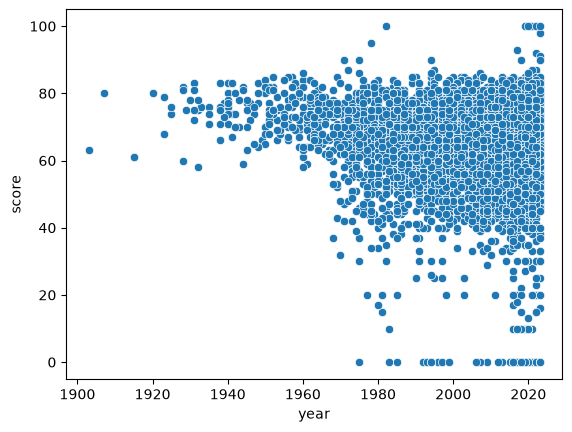

In [8]:
sns.scatterplot(df, x=df['year'], y=df['score'])

<Axes: xlabel='month', ylabel='score'>

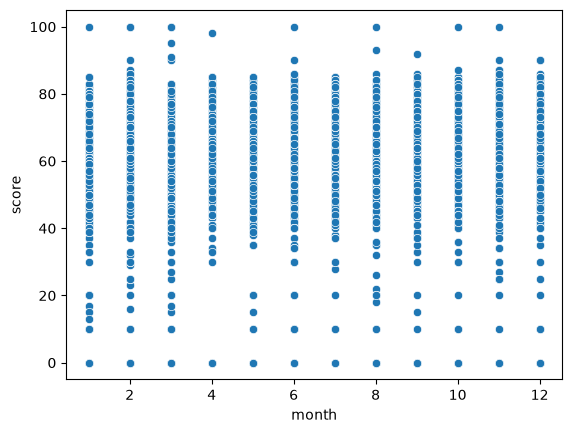

In [15]:
sns.scatterplot(data=df, x=df['month'], y=df['score'])

In [18]:
df['genre'].unique()

<StringArray>
[                                       'Drama, Action',
                   'Science Fiction, Adventure, Action',
        'Animation, Adventure, Family, Fantasy, Comedy',
        'Animation, Comedy, Family, Adventure, Fantasy',
                                               'Action',
                              'Thriller, Comedy, Crime',
                              'Action, Thriller, Crime',
        'Animation, Family, Fantasy, Adventure, Comedy',
                              'Action, Science Fiction',
     'Action, Drama, Horror, Science Fiction, Thriller',
 ...
                                'Drama, Music, Fantasy',
                                  'Crime, Drama, Music',
              'Action, Comedy, Thriller, Crime, Family',
                    'Adventure, Drama, Action, History',
                      'Drama, Thriller, Mystery, Crime',
                               'History, Drama, Family',
        'Adventure, Fantasy, Animation, Comedy, Family',
   'Adventur

In [20]:
genres = df["genre"].fillna("").apply(
    lambda s: [g.strip() for g in s.split(",") if g.strip()]
)

mlb = MultiLabelBinarizer()
genre_features = pd.DataFrame(
    mlb.fit_transform(genres),
    columns=mlb.classes_,
    index=df.index
)

display(genre_features.head())

,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,0,1,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0
3,0,1,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [21]:
mlb.classes_

array(['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror',
       'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie',
       'Thriller', 'War', 'Western'], dtype=object)

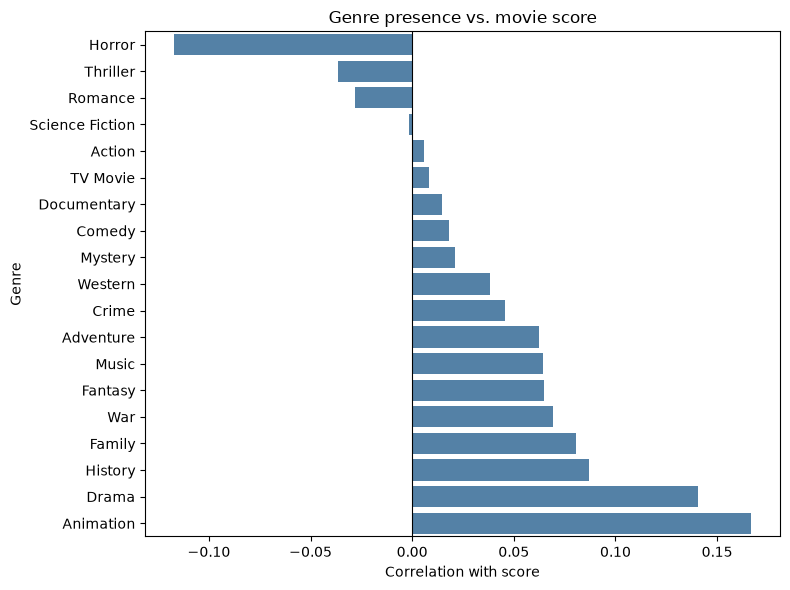

In [23]:
correlations = (
    genre_features.corrwith(df["score"])
    .dropna()
    .sort_values()
)

plt.figure(figsize=(8, 6))
sns.barplot(x=correlations.values, y=correlations.index, color="steelblue")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Correlation with score")
plt.ylabel("Genre")
plt.title("Genre presence vs. movie score")
plt.tight_layout()
plt.show()

In [24]:
df['orig_lang'].unique()

<StringArray>
[                            ' English',
                  ' Spanish, Castilian',
                           ' Norwegian',
                            ' Japanese',
                              ' Korean',
                             ' Russian',
                           ' Cantonese',
                           ' Ukrainian',
                             ' Italian',
                              ' German',
                              ' French',
                             ' Finnish',
                  ' Catalan, Valencian',
                           ' Icelandic',
                          ' Indonesian',
                      ' Dutch, Flemish',
                          ' Portuguese',
                              ' Telugu',
                              ' Polish',
                              ' Danish',
                             ' Turkish',
                             ' Chinese',
                                ' Thai',
                            ' Romanian',
  

In [25]:
df['budget_x']

0         75000000.0
1        460000000.0
2        100000000.0
3         12300000.0
4         77000000.0
            ...     
10173      7000000.0
10174      9145817.8
10175     21800000.0
10176    116000000.0
10177     92400000.0
Name: budget_x, Length: 10178, dtype: float64